In [21]:
import pandas as pd
import matplotlib.pyplot as plt
def dibuja(ruta_archivo, nombre='Métricas de Entrenamiento del Modelo (train/test)', maximum=False):

    # El parámetro lines=True le indica a Pandas que lea un JSON distinto en cada línea del txt
    df = pd.read_json(ruta_archivo, lines=True)

    # Establecemos la 'epoch' como el índice (será nuestro eje X)
    df.set_index('epoch', inplace=True)

    # 2. Configurar el lienzo (4 gráficos en una cuadrícula de 2x2)
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(nombre, fontsize=16, fontweight='bold')

    # Gráfico A: Loss (Pérdida)
    axes[0, 0].plot(df.index, df['train_loss'], label='Train Loss', marker='o')
    axes[0, 0].plot(df.index, df['test_loss'], label='Test Loss', marker='s')
    axes[0, 0].set_title('Pérdida (Loss)')
    axes[0, 0].set_xlabel('Época')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Gráfico B: Métricas de texto (BLEU & ROUGE)
    # Extraemos solo las columnas que nos interesan para este gráfico
    bleu_cols = ['test_bleu1', 'test_bleu2', 'test_bleu3', 'test_bleu4', 'test_rouge']
    for col in bleu_cols:
        # Verificamos que la columna exista en el archivo por seguridad
        if col in df.columns: 
            line, = axes[0, 1].plot(df.index, df[col], label=col.replace('test_', '').upper(), marker='o')
            if maximum:
                max_val = df[col].max()
                max_idx = df[col].idxmax()
                axes[0, 1].plot(max_idx, max_val, marker='*', markersize=14, color=line.get_color(), markeredgecolor='black')
                axes[0, 1].annotate(f'{max_val:.2f}', 
                                    (max_idx, max_val), 
                                    textcoords="offset points", 
                                    xytext=(0, 10), # Offset text slightly above the star
                                    ha='center', 
                                    color=line.get_color(), 
                                    fontweight='bold')
            
    axes[0, 1].set_title('Métricas de Texto (más mejor)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)
    
    # Gráfico C: WER (Tasa de error de palabras)
    axes[1, 0].plot(df.index, df['test_wer'], label='Test WER', color='red', marker='o')
    axes[1, 0].set_title('Tasa de Error de Palabras (menos mejor)')
    axes[1, 0].set_xlabel('Época')
    axes[1, 0].set_ylabel('WER (%)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)
    if maximum: # Estrella en minimo
        min_wer = df['test_wer'].min()
        min_wer_idx = df['test_wer'].idxmin()
        axes[1, 0].plot(min_wer_idx, min_wer, marker='*', markersize=16, color='darkred', markeredgecolor='black')
        axes[1, 0].annotate(f'{min_wer:.2f}', 
                    (min_wer_idx, min_wer), 
                    textcoords="offset points", 
                    xytext=(0, -15),
                    ha='center', 
                    color='darkred', 
                    fontweight='bold')
        
    # Gráfico D: Learning Rate
    axes[1, 1].plot(df.index, df['train_lr'], label='Learning Rate', color='purple', marker='o')
    axes[1, 1].set_title('Tasa de Aprendizaje')
    axes[1, 1].set_xlabel('Época')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    # Ajustar diseño y mostrar
    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Deja espacio para el título principal
    plt.show()
    return fig

def dibuja_SLR(ruta_archivo, nombre='Métricas de Entrenamiento del Modelo (train/test)', maximum=False):
    # El parámetro lines=True le indica a Pandas que lea un JSON distinto en cada línea del txt
    df = pd.read_json(ruta_archivo, lines=True)

    df.set_index('epoch', inplace=True)

    fig, axes = plt.subplots(1, 3, figsize=(30, 10))
    fig.suptitle(nombre, fontsize=16, fontweight='bold')

    # Gráfico 1: Loss
    axes[0].plot(df.index, df['train_loss'], label='Train Loss', marker='o', markersize=10)
    axes[0].plot(df.index, df['test_loss'], label='Test Loss', marker='s', markersize=10)
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Gráfico 2: WER
    axes[1].plot(df.index, df['test_wer'], label='Test WER', color='red', marker='o', markersize=10)
    axes[1].set_title('Tasa de Error de Palabras (menos mejor)')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('WER (%)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)
    if maximum: # Estrella en minimo
        min_wer = df['test_wer'].min()
        min_wer_idx = df['test_wer'].idxmin()
        axes[1].plot(min_wer_idx, min_wer, marker='*', markersize=16, color='darkred', markeredgecolor='black')
        axes[1].annotate(f'{min_wer:.2f}', 
                    (min_wer_idx, min_wer), 
                    textcoords="offset points", 
                    xytext=(0, -15),
                    ha='center', 
                    color='darkred', 
                    fontweight='bold')

    # Gráfico 3: Learning Rate
    axes[2].plot(df.index, df['train_lr'], label='Learning Rate', color='purple', marker='o', markersize=10)
    axes[2].set_title('Tasa de Aprendizaje')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LR')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    return fig

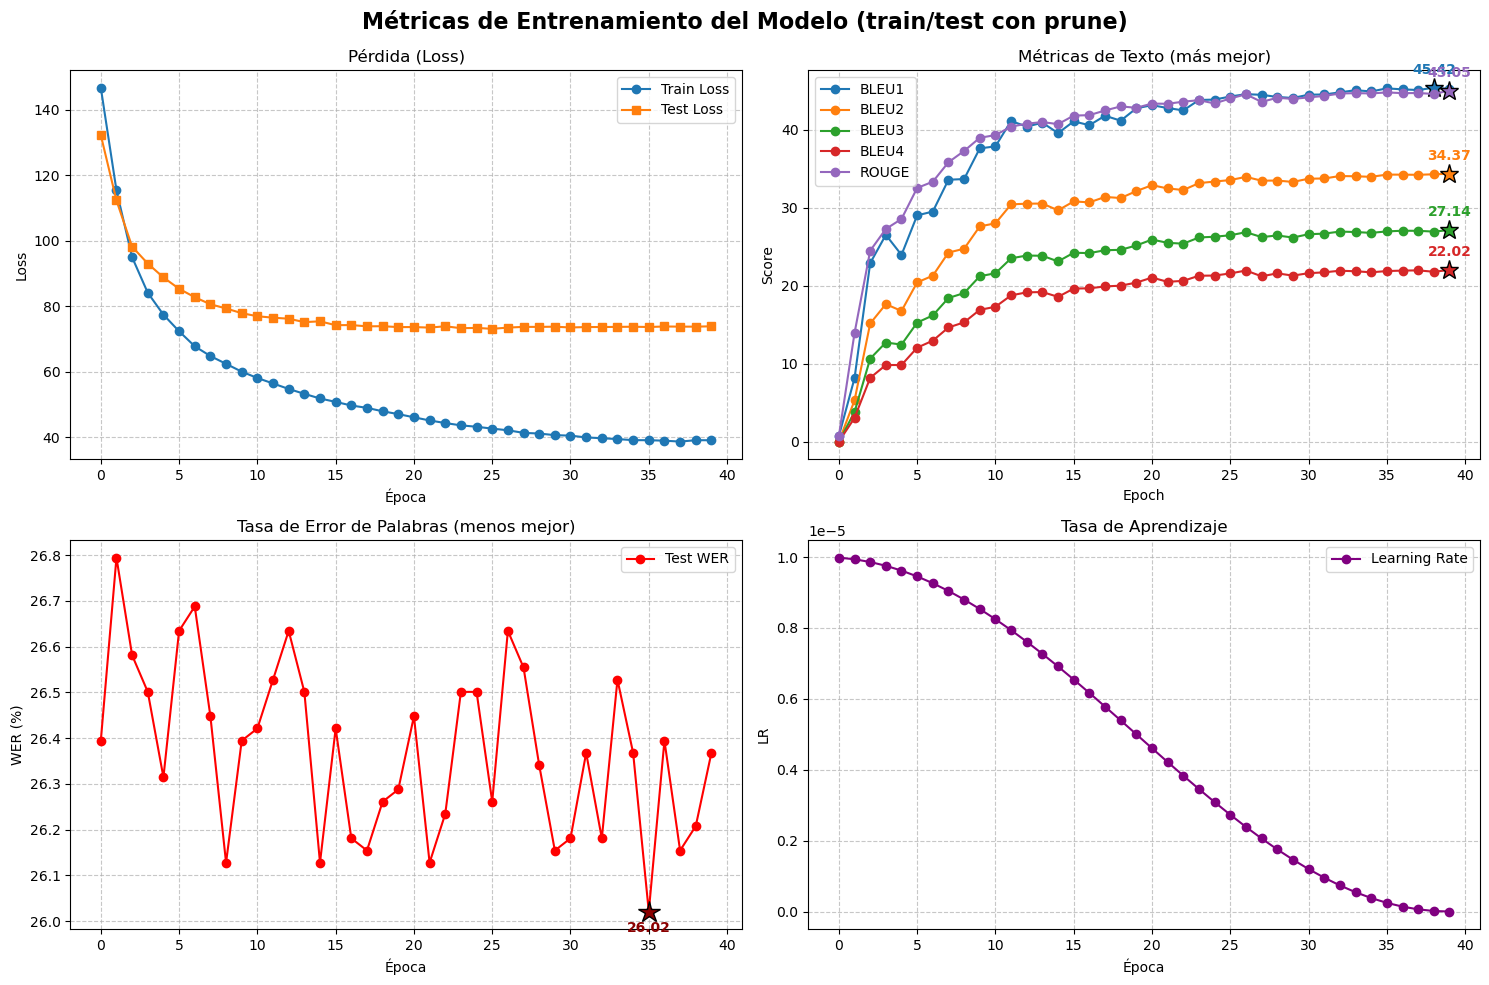

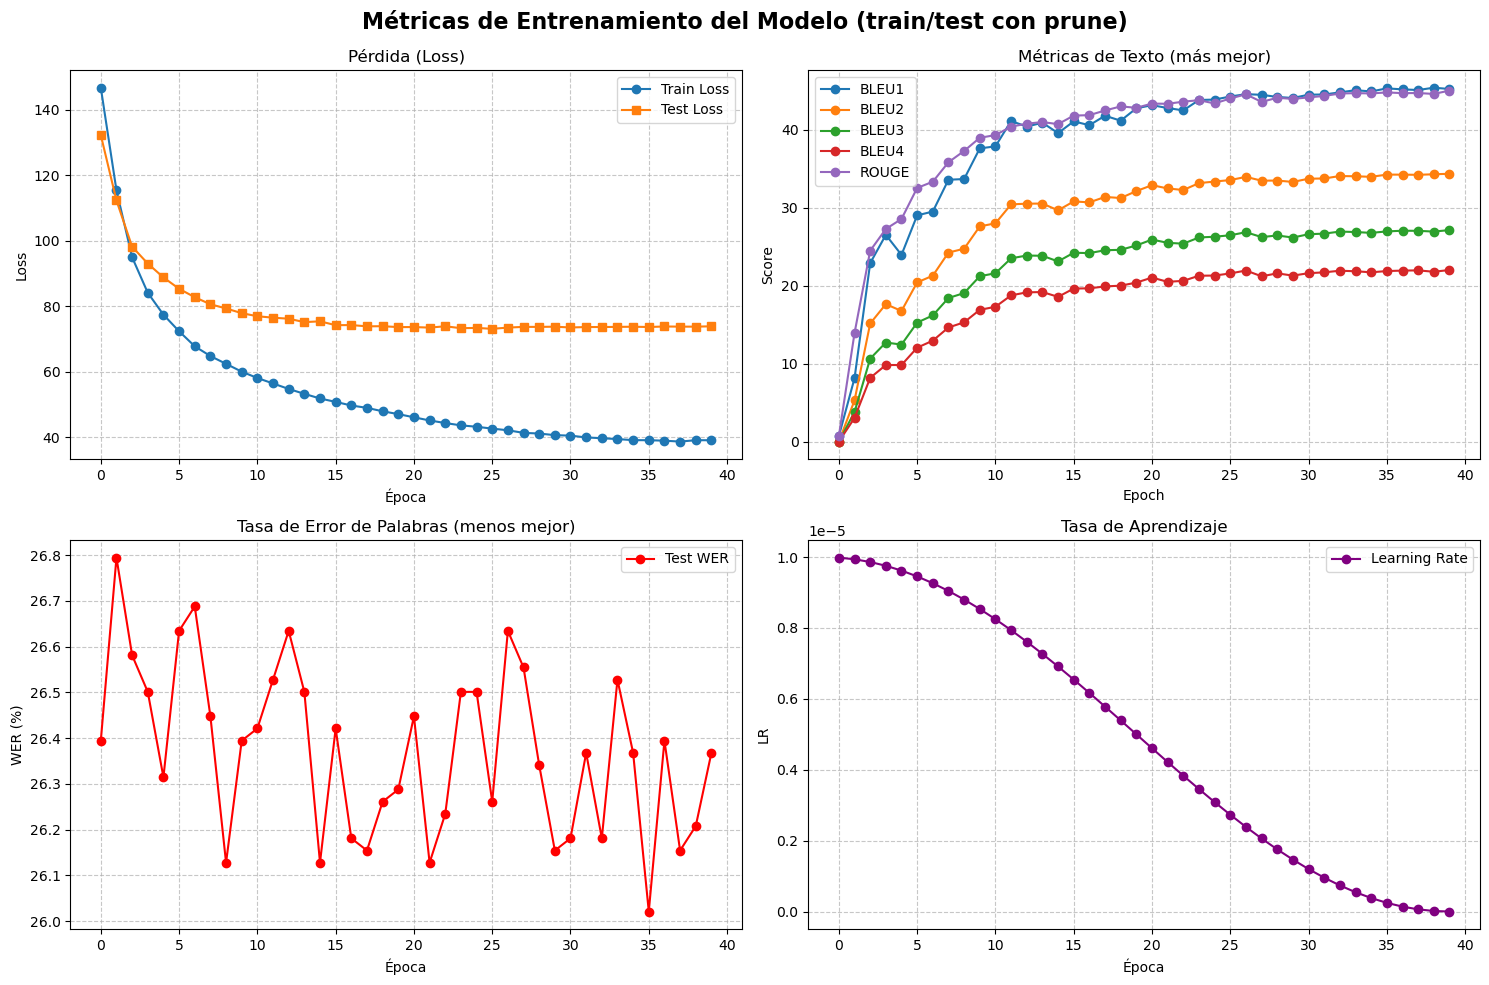

In [14]:
fig = dibuja("phoenix-2014T_SLT_prune/log.txt", "Métricas de Entrenamiento del Modelo (train/test con prune)", maximum=True)
fig.savefig("figs/phoenix-2014T_SLT_prune_max.png")
fig = dibuja("phoenix-2014T_SLT_prune/log.txt", "Métricas de Entrenamiento del Modelo (train/test con prune)", maximum=False)
fig.savefig("figs/phoenix-2014T_SLT_prune.png")

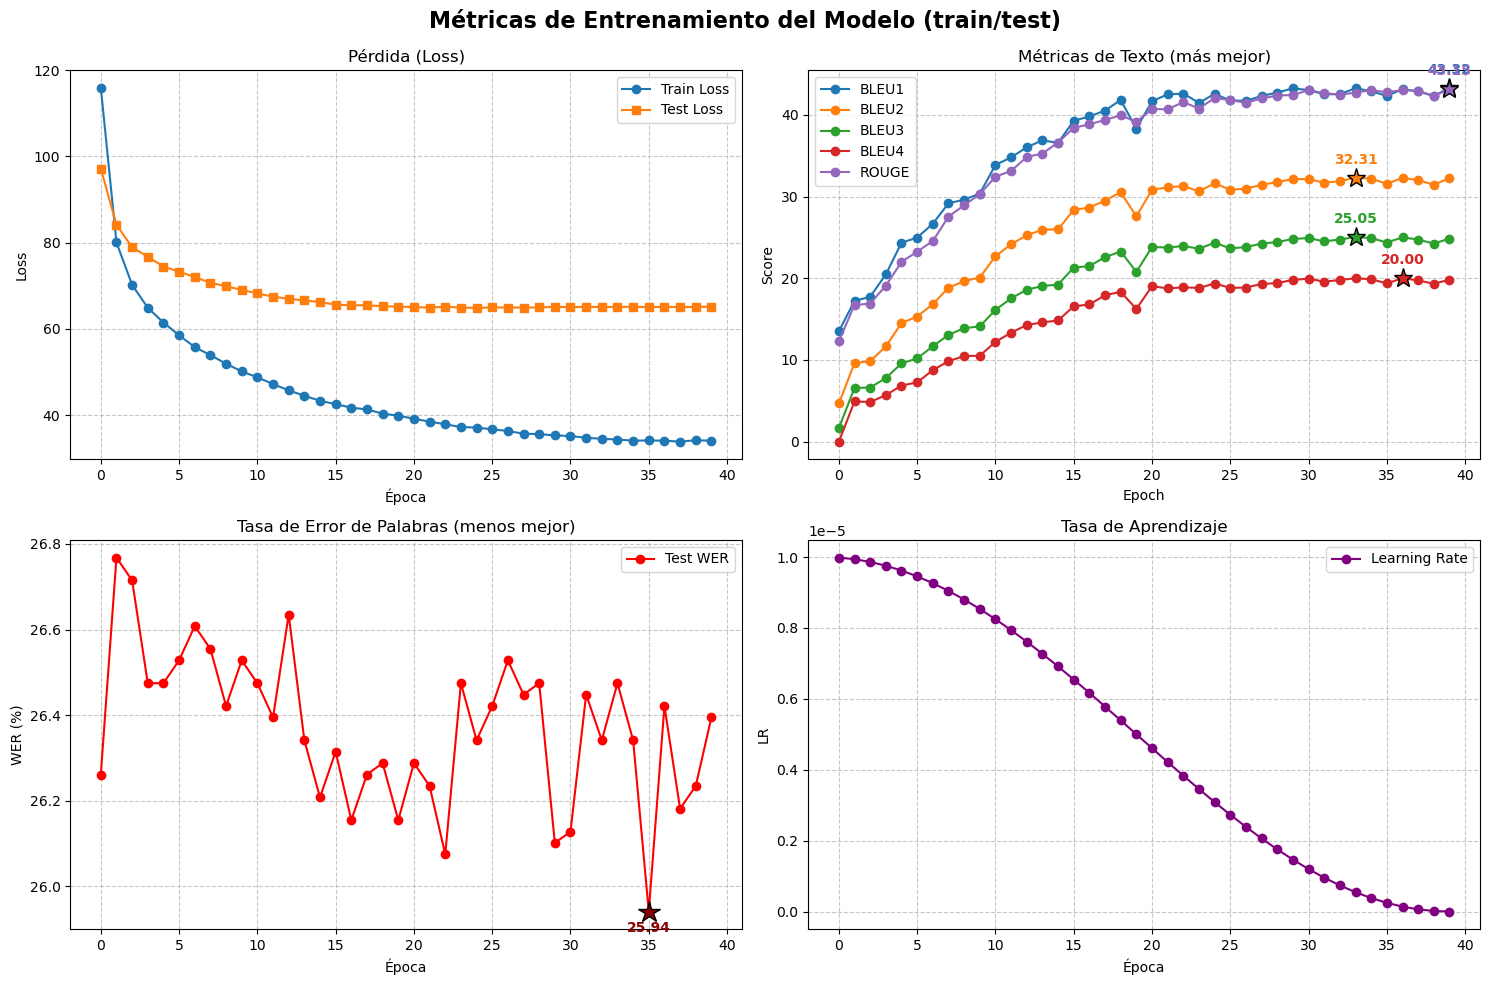

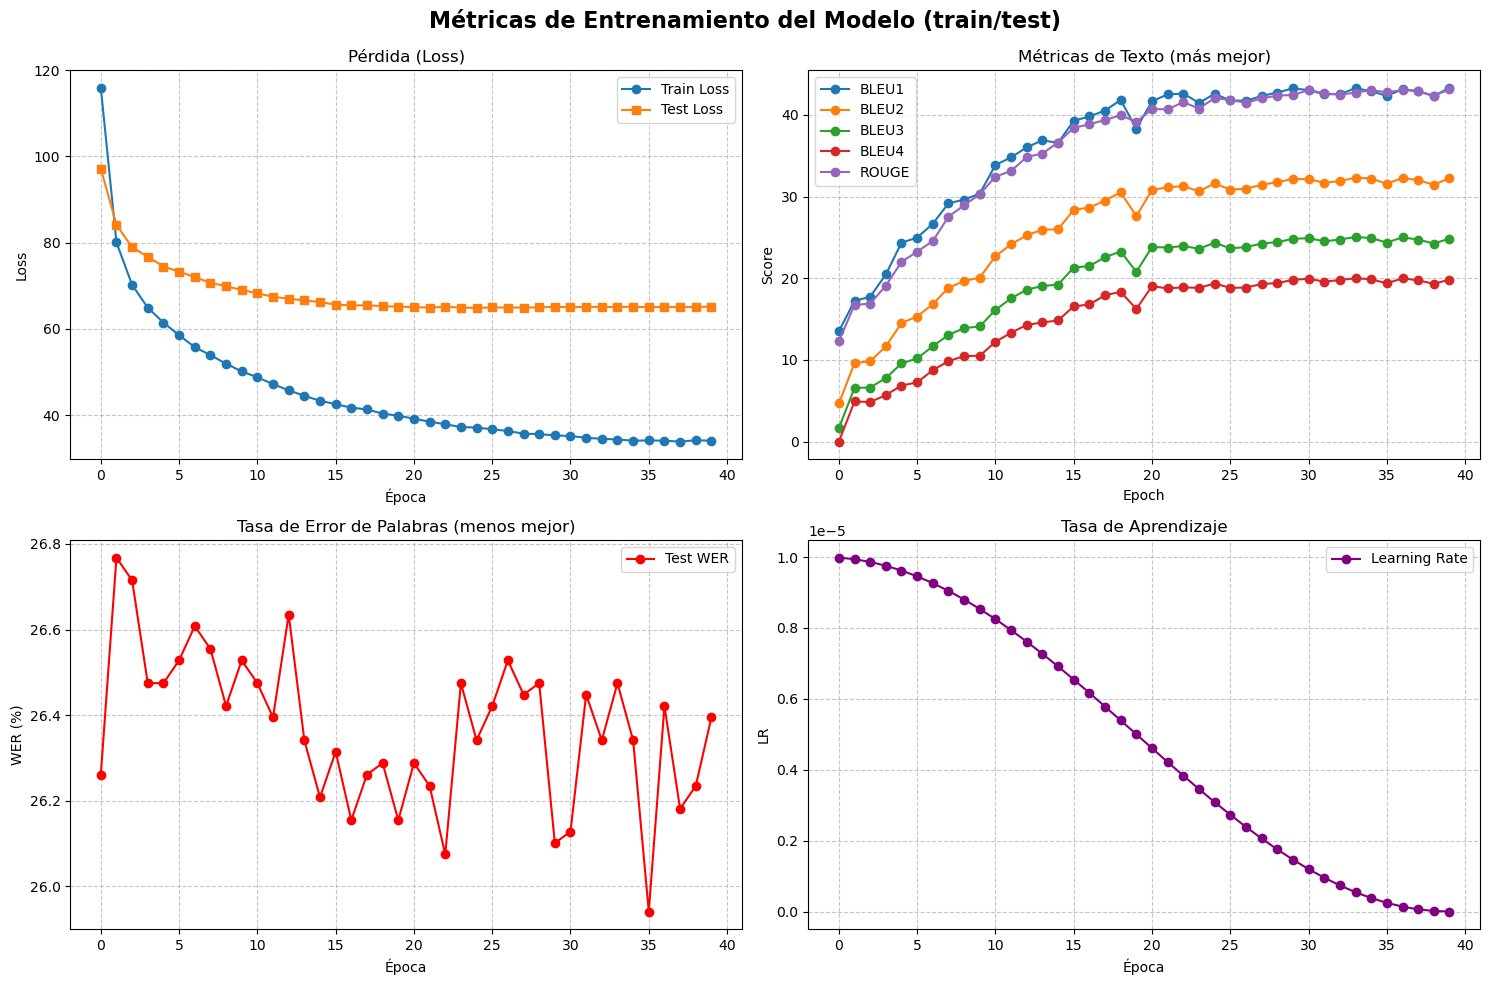

In [15]:
fig = dibuja("outputs/phoenix-2014T_SLT/log.txt", maximum=True)
fig.savefig("figs/phoenix-2014T_SLT_max.png")
fig = dibuja("outputs/phoenix-2014T_SLT/log.txt", maximum=False)
fig.savefig("figs/phoenix-2014T_SLT.png")

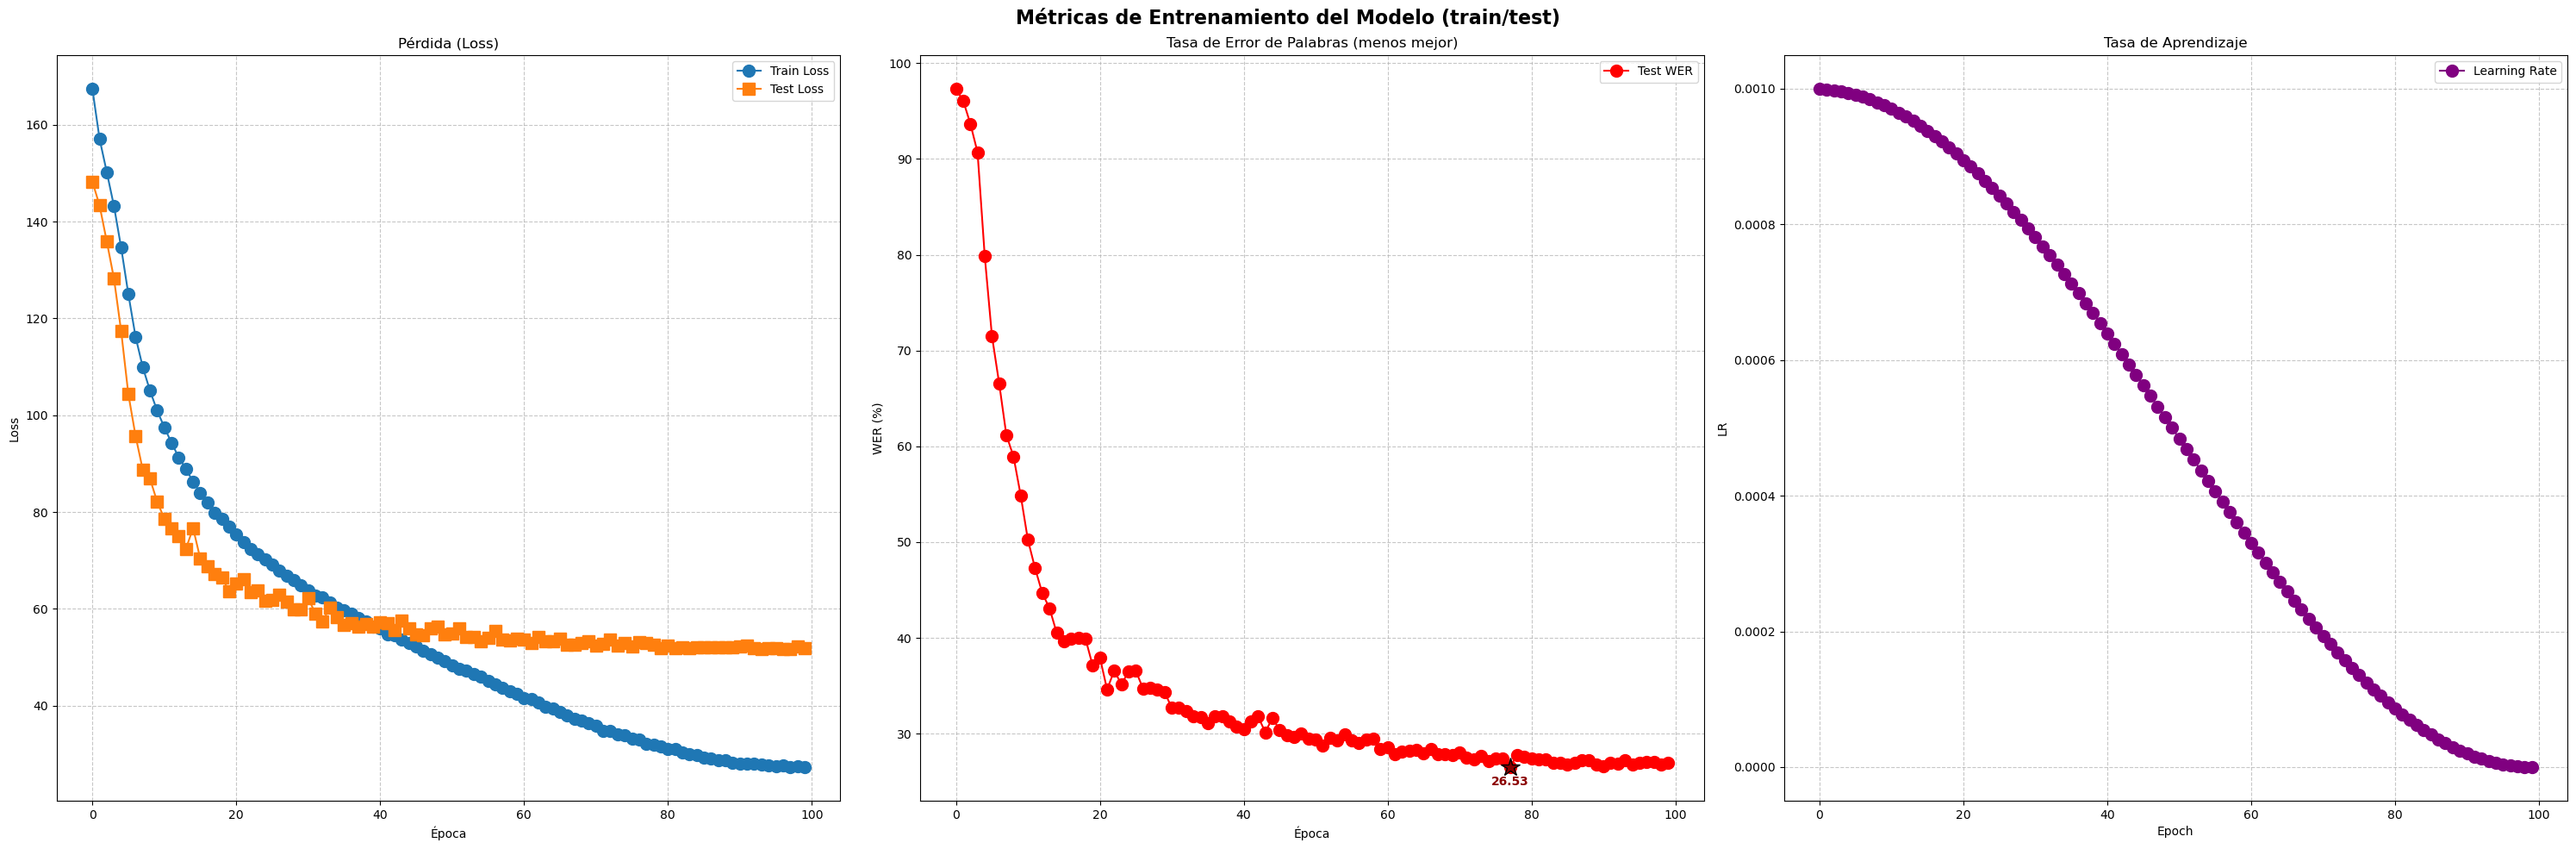

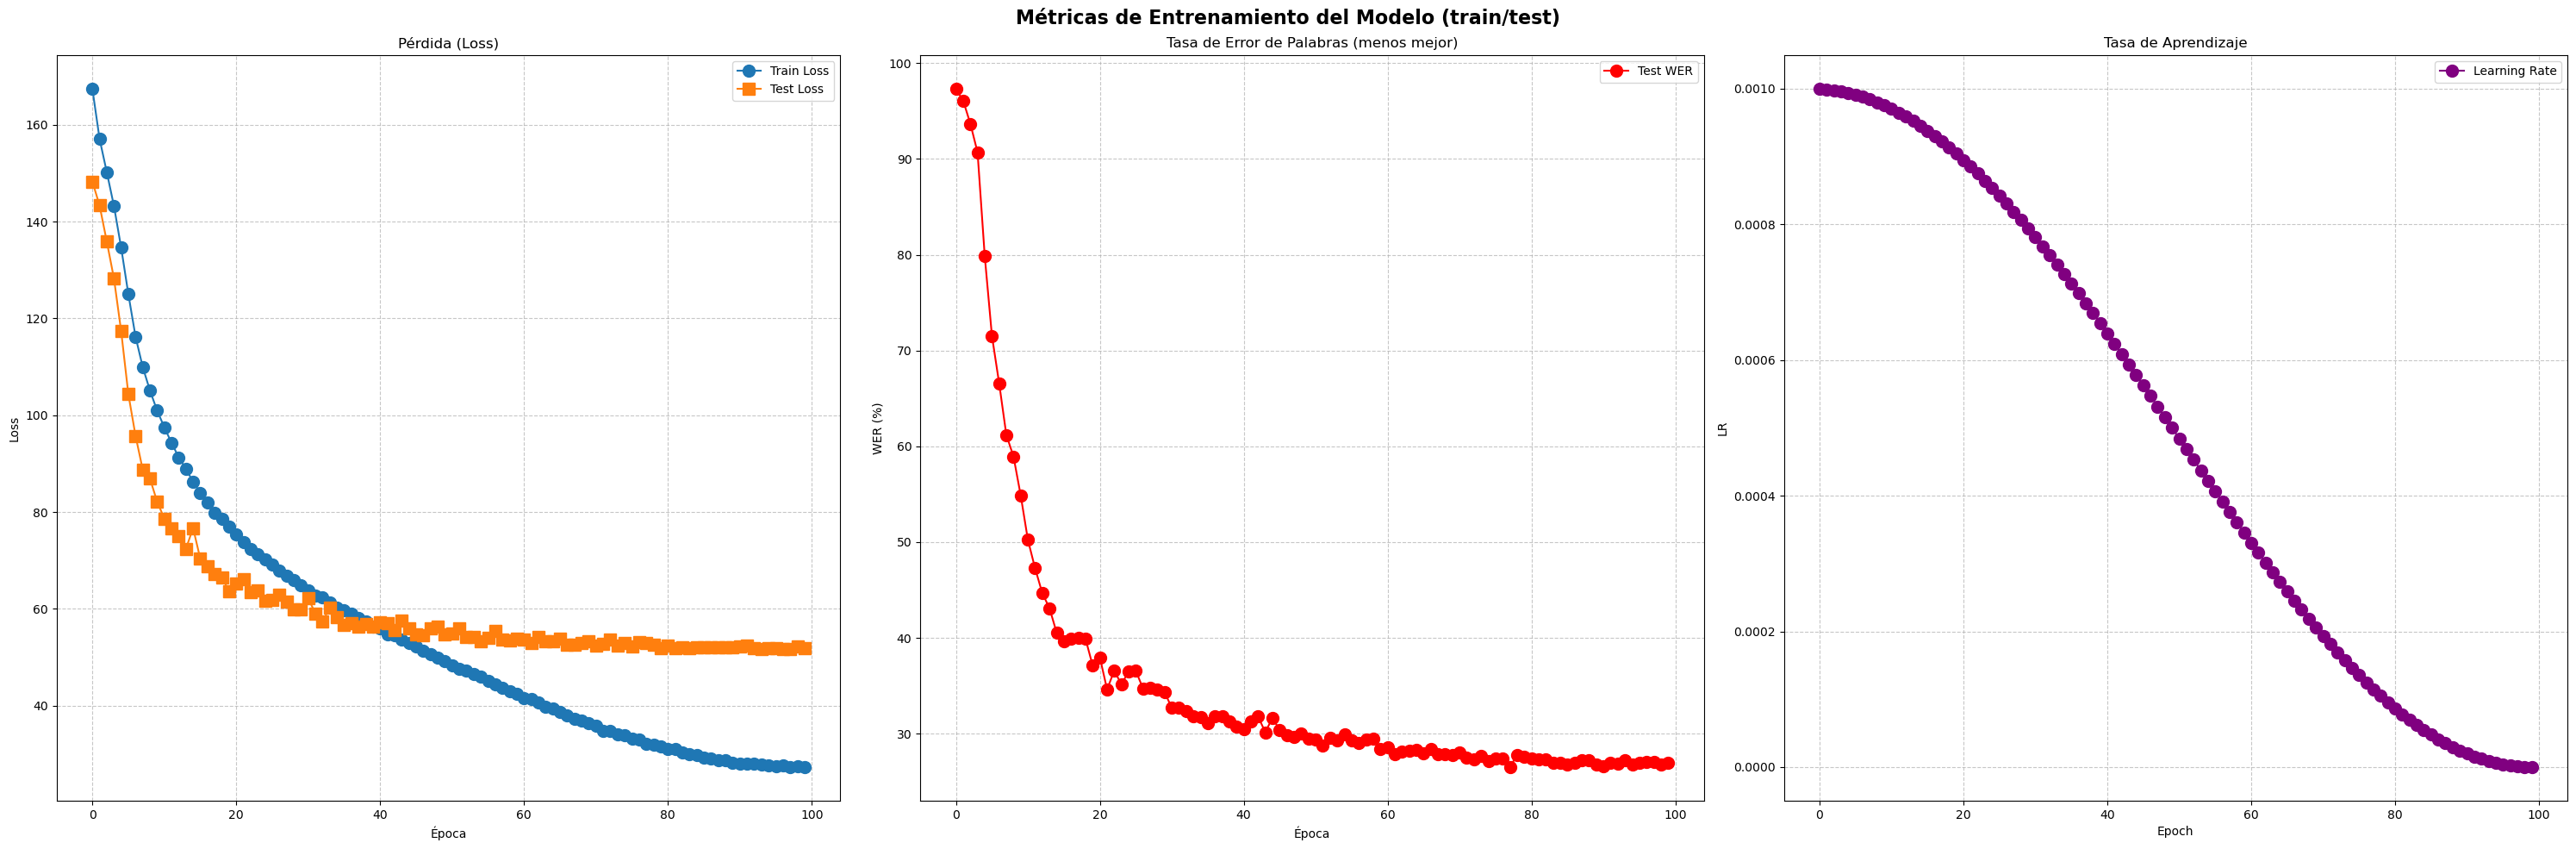

In [22]:
fig = dibuja_SLR("outputs/Phoenix-2014T_SLR/log.txt", maximum=True)
fig.savefig("figs/phoenix-2014T_SLR_max.png")
fig = dibuja_SLR("outputs/Phoenix-2014T_SLR/log.txt", maximum=False)
fig.savefig("figs/phoenix-2014T_SLR.png")